#Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ml models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.linear_model import LogisticRegression# Logistic regression
from sklearn.neighbors import KNeighborsClassifier # K-nn
from sklearn.naive_bayes import GaussianNB # Naive bayes
from sklearn.svm import SVC
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier

# splitting test_train
from sklearn.model_selection import train_test_split
#cross validation
from sklearn.model_selection import KFold, cross_val_score
# evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score




LOAD DATA SET

In [2]:
data = pd.read_csv("beer-servings.csv")

In [3]:
#from google.colab import drive
#drive.mount('/content/drive')

In [4]:
data.head()

,Unnamed: 0,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,0,Afghanistan,0.0,0.0,0.0,0.0,Asia
1,1,Albania,89.0,132.0,54.0,4.9,Europe
2,2,Algeria,25.0,0.0,14.0,0.7,Africa
3,3,Andorra,245.0,138.0,312.0,12.4,Europe
4,4,Angola,217.0,57.0,45.0,5.9,Africa


In [5]:
data.describe()

,Unnamed: 0,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
count,193.000000,185.000000,185.000000,187.000000,192.000000
mean,96.000000,105.124324,83.221622,50.165775,4.741667
std,55.858452,100.524714,89.142958,80.358868,3.767654
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,20.000000,4.000000,1.000000,1.300000
50%,96.000000,76.000000,60.000000,9.000000,4.250000
75%,144.000000,185.000000,132.000000,60.500000,7.200000
max,192.000000,376.000000,438.000000,370.000000,14.400000


In [6]:
print(data.shape)
print(data.info())
print(data.describe())

(193, 7)
<class 'pandas.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    193 non-null    int64  
 1   country                       193 non-null    str    
 2   beer_servings                 185 non-null    float64
 3   spirit_servings               185 non-null    float64
 4   wine_servings                 187 non-null    float64
 5   total_litres_of_pure_alcohol  192 non-null    float64
 6   continent                     193 non-null    str    
dtypes: float64(4), int64(1), str(2)
memory usage: 13.5 KB
None
       Unnamed: 0  beer_servings  spirit_servings  wine_servings  \
count  193.000000     185.000000       185.000000     187.000000   
mean    96.000000     105.124324        83.221622      50.165775   
std     55.858452     100.524714        89.142958      80.358868   
min      0.000000       0.00000

In [7]:
data.isnull().sum()

Unnamed: 0                      0
country                         0
beer_servings                   8
spirit_servings                 8
wine_servings                   6
total_litres_of_pure_alcohol    1
continent                       0
dtype: int64

In [8]:
data.duplicated().sum()

#data.drop_duplicates(inplace = True)

np.int64(0)

In [9]:
missing_percent = data.isna().sum()/ len(data)* 100

print(missing_percent)

Unnamed: 0                      0.000000
country                         0.000000
beer_servings                   4.145078
spirit_servings                 4.145078
wine_servings                   3.108808
total_litres_of_pure_alcohol    0.518135
continent                       0.000000
dtype: float64


In [10]:
num_cols = data.select_dtypes(include =["number"]).columns
cat_cols = data.select_dtypes(include =["object"]).columns

C:\Users\user\AppData\Local\Temp\ipykernel_21224\1830098932.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data.select_dtypes(include =["object"]).columns


In [11]:
num_cols

Index(['Unnamed: 0', 'beer_servings', 'spirit_servings', 'wine_servings',
       'total_litres_of_pure_alcohol'],
      dtype='str')

In [12]:
cat_cols

Index(['country', 'continent'], dtype='str')

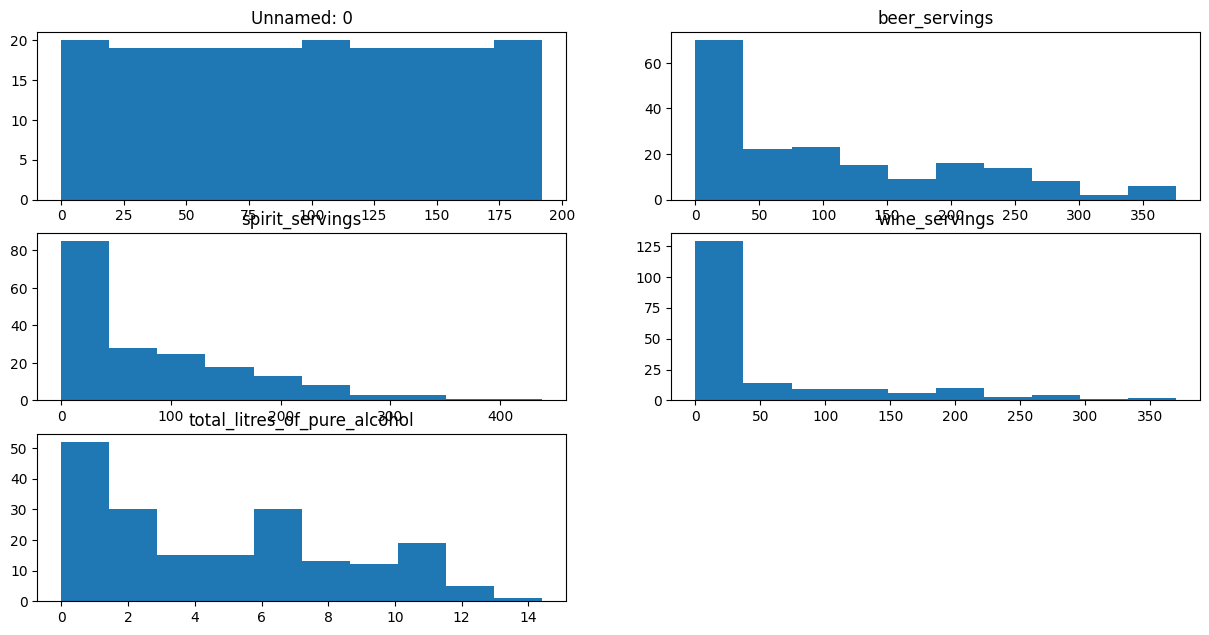

In [13]:
plt.figure(figsize=(15,10))
for i,col in enumerate(num_cols, 1):
  plt.subplot(4,2,i)
  plt.hist(data[col])
  plt.title(col, fontsize=10)
  plt.title(col)

plt.show()

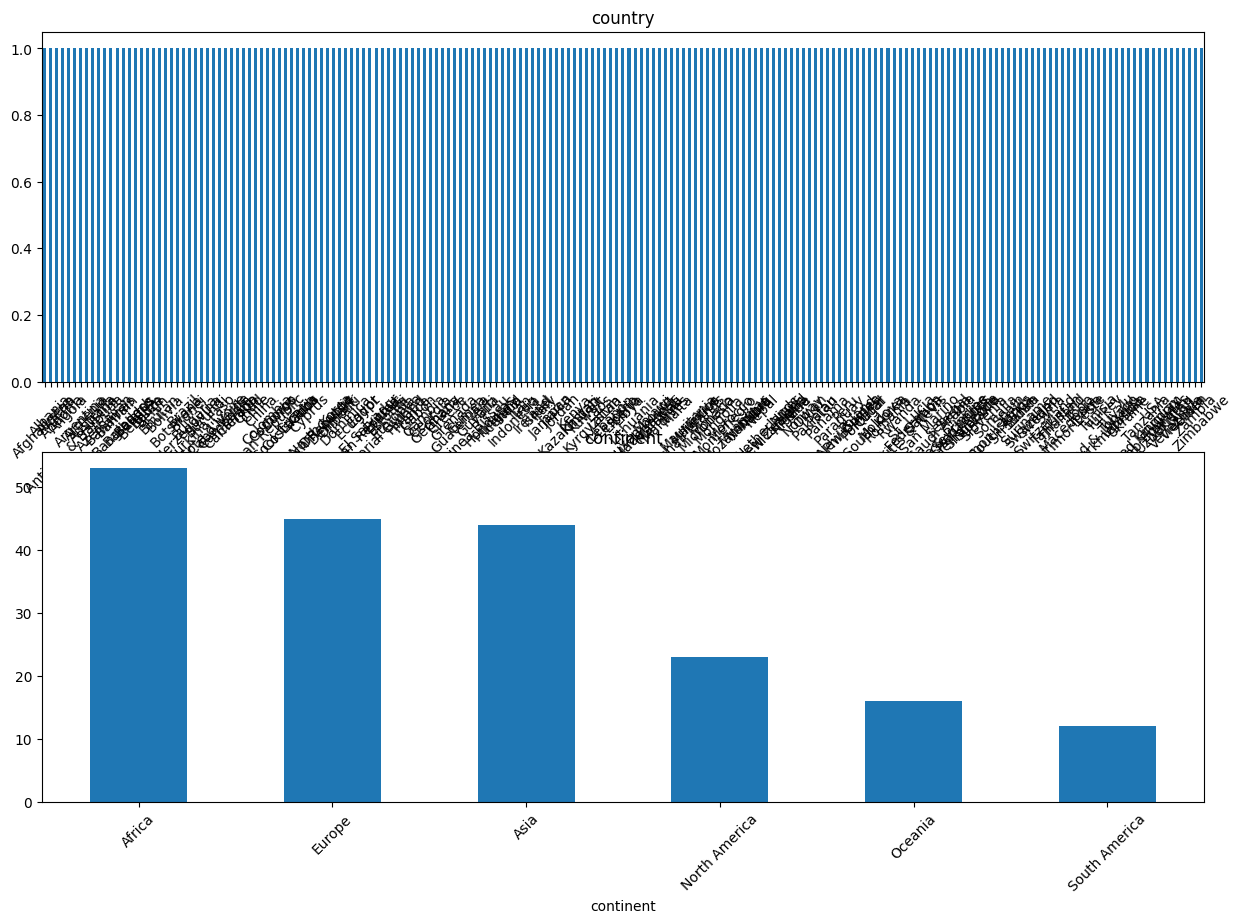

In [14]:
# plots to understand categorical value distribution
plt.figure(figsize= (15,10))
for i,col in enumerate(cat_cols, 1):
  #plt.subplot(2, 2, i)
  plt.subplot(2,1, i)
  data[col].value_counts().plot(kind ='bar')
  plt.title(col)
  plt.xticks(rotation = 45)
plt.tight_layout
plt.show()

Missing value handling
1.Remove
1.1 Remove rows: if a count of missing value is more than 30% of the no. of rows, we remove coulmn itself.

1.1 Remove columns: when we know that removal of a row doesnt make much difference in terms of available data for ML model building

2.Replace

2.1 Mode: if the colums has non numerical data

2.2 Mean : if that data distribution of the coulmn is symmetrical(normal distribution)

2.3 Median: if that data distribution of the coulmn is not symmetrical(skwed distribution)

In [15]:
data.fillna(data.median(numeric_only=True), inplace=True)

,Unnamed: 0,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,0,Afghanistan,0.0,0.0,0.0,0.0,Asia
1,1,Albania,89.0,132.0,54.0,4.9,Europe
2,2,Algeria,25.0,0.0,14.0,0.7,Africa
3,3,Andorra,245.0,138.0,312.0,12.4,Europe
4,4,Angola,217.0,57.0,45.0,5.9,Africa
...,...,...,...,...,...,...,...
188,188,Venezuela,76.0,100.0,3.0,7.7,South America
189,189,Vietnam,111.0,2.0,1.0,2.0,Asia
190,190,Yemen,6.0,0.0,0.0,0.1,Asia
191,191,Zambia,32.0,19.0,4.0,2.5,Africa


In [16]:
#for mode:
#data['column name'].fillna(
    #data['column'].mode()[0],
    #inplace=True
#)

In [17]:
data.isna().sum()

Unnamed: 0                      0
country                         0
beer_servings                   0
spirit_servings                 0
wine_servings                   0
total_litres_of_pure_alcohol    0
continent                       0
dtype: int64

In [18]:
#removed unwanted columns
data.drop(
    ['Unnamed: 0','country'],
    axis=1,
    errors='ignore',
    inplace=True
)

##EDA

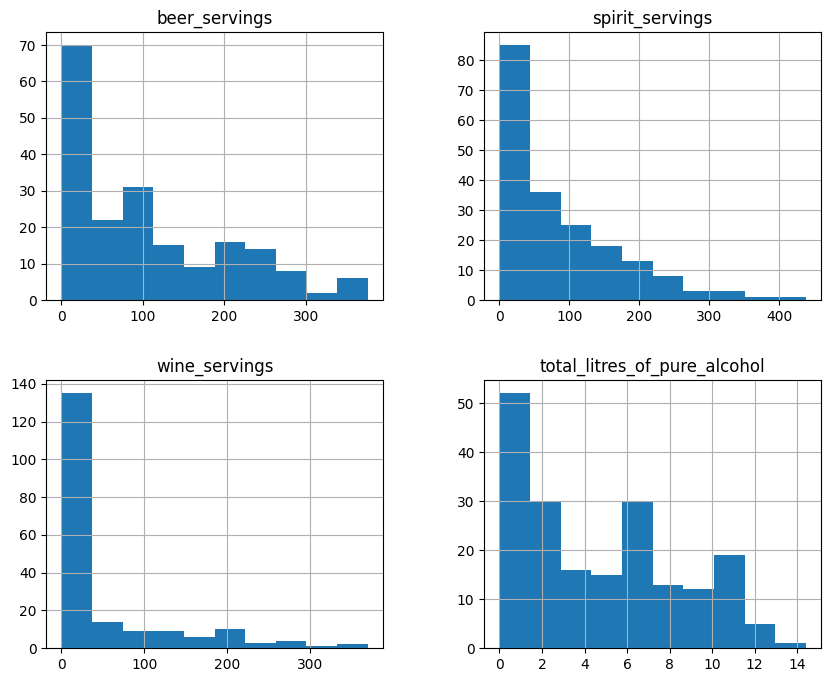

In [19]:
data.hist(figsize=(10,8))
plt.show()

##OUTLIERS

quartile and IQR plays a role in identifying outliers
Q1 = 25% of the column (25th percentile)

Q2 = 50% of the column (55th percentile)

Q3 = 75% of the column (75th percentile)

Range = Max -Min

IQR = Q3-Q1

IQR :Inter Quartile Range

Upper limit = Q3 + (1.5 * IQR)

Lower Limit = Q1 -(1.5 * IQR)

Outerlier : any value > upper limit or value < lower limit we handle outliers bcoz they can skew the general nature of the ML model

In [20]:
data.describe()

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
count,193.000000,193.000000,193.00000,193.000000
mean,103.917098,82.259067,48.88601,4.739119
std,98.580146,87.389366,79.41700,3.757996
min,0.000000,0.000000,0.00000,0.000000
25%,21.000000,5.000000,1.00000,1.300000
50%,76.000000,60.000000,9.00000,4.250000
75%,171.000000,128.000000,59.00000,7.200000
max,376.000000,438.000000,370.00000,14.400000


In [21]:
print(num_cols)

Index(['Unnamed: 0', 'beer_servings', 'spirit_servings', 'wine_servings',
       'total_litres_of_pure_alcohol'],
      dtype='str')


In [22]:
data.drop(
    ['Unnamed: 0','country'],
    axis=1,
    errors='ignore',
    inplace=True
)

In [23]:
print(data.columns.tolist())
print(num_cols)

['beer_servings', 'spirit_servings', 'wine_servings', 'total_litres_of_pure_alcohol', 'continent']
Index(['Unnamed: 0', 'beer_servings', 'spirit_servings', 'wine_servings',
       'total_litres_of_pure_alcohol'],
      dtype='str')


In [24]:
num_cols = data.select_dtypes(include=np.number).columns
print(num_cols)

Index(['beer_servings', 'spirit_servings', 'wine_servings',
       'total_litres_of_pure_alcohol'],
      dtype='str')


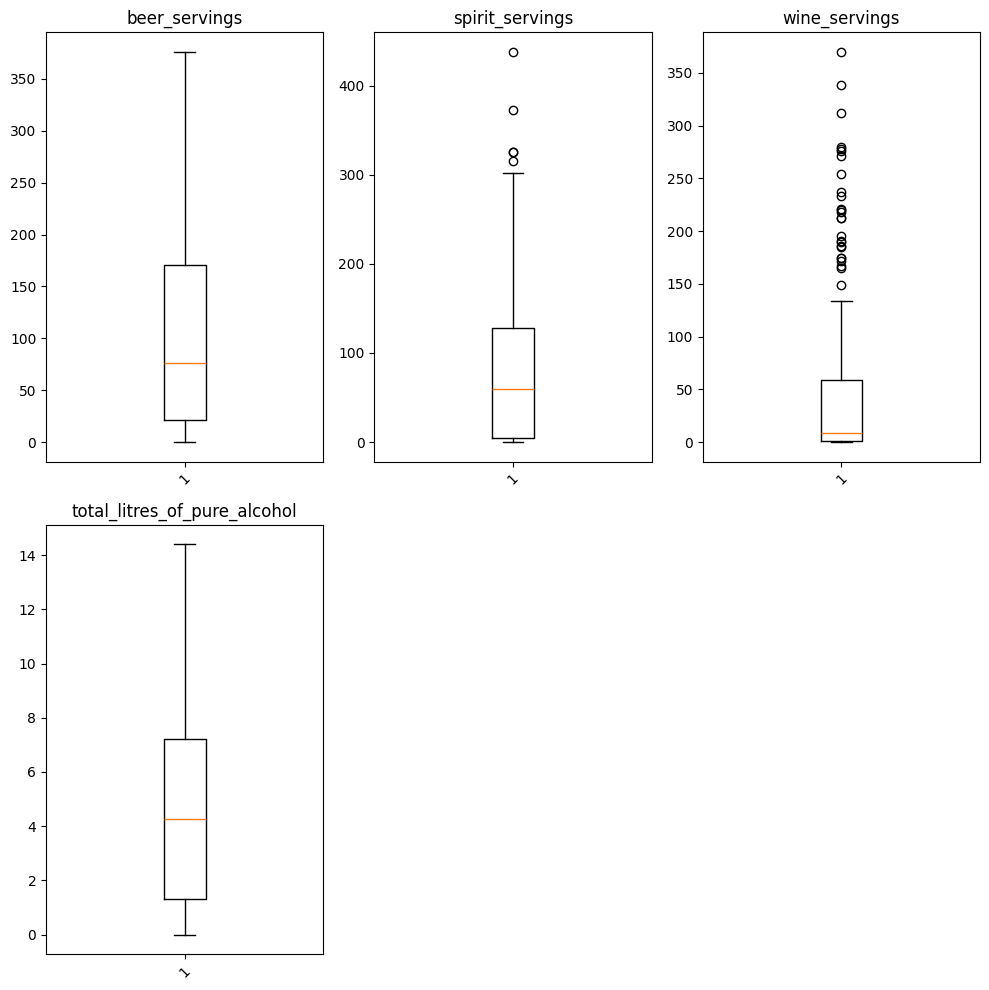

In [25]:
plt.figure(figsize=(10,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(data[col])
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [26]:
#outlier handling can be done in 2 ways
##Identify outliers
#Values below lower limit → outliers
#Values above upper limit → outliers
# 1.removing all rows where outliers are present
# 2. clipping the values to upper limit and lower limit

In [27]:
Q1 = data[num_cols].quantile(0.25)

Q3 = data[num_cols].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3+ (1.5 * IQR)
lower_limit = Q1- (1.5 * IQR)

outliers = ((data[num_cols] > upper_limit)|(data[num_cols] < lower_limit)).any(axis = 1)

outliers_df = data[outliers]
outlier_percentage = len(outliers_df)* 100/len(data)

print('percentage of outliers in the dataframe: ', outlier_percentage)

percentage of outliers in the dataframe:  16.06217616580311


In [28]:
#option 2 : clipping
#customer_df[num_cols] = customer_df[num_cols].clip(lower_limit, upper_limit, axis=1)
# axis =1 means along with column direction

In [29]:
data[num_cols] = data[num_cols].clip(lower_limit, upper_limit, axis=1)

In [30]:
#data['wine_servings'] = data['wine_servings'].clip(
    #lower=lower_limit,
    #upper=upper_limit
#)

In [31]:
#data['spirit_servings'] = data['spirit_servings'].clip(
    #lower=lower_limit,
    #upper=upper_limit
#)

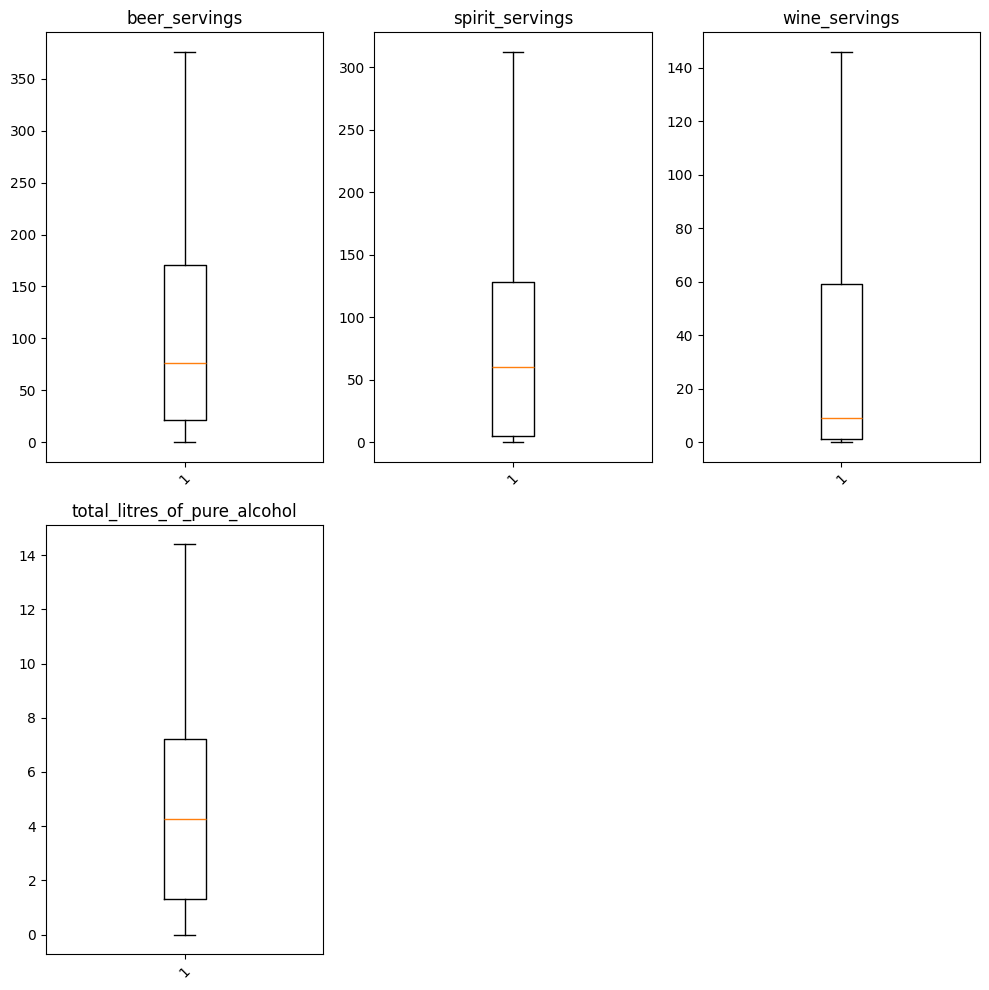

In [32]:
plt.figure(figsize=(10,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(data[col])
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#Encoding
label_encoder = LabelEncoder()

customer_df["city"] = label_encoder.fit_transform(customer_df["city"])

customer_df["gender"] = label_encoder.fit_transform(customer_df["gender"])

doing one hot encoding on mentioned coulmns
customer_df = pd.get_dummies(customer_df, columns =['education_level'],dtype =int)

In [33]:
data = pd.get_dummies(
    data,
    columns=['continent'],
    drop_first=True
)

In [34]:
data.head()

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America
0,0.0,0.0,0.0,0.0,True,False,False,False,False
1,89.0,132.0,54.0,4.9,False,True,False,False,False
2,25.0,0.0,14.0,0.7,False,False,False,False,False
3,245.0,138.0,146.0,12.4,False,True,False,False,False
4,217.0,57.0,45.0,5.9,False,False,False,False,False


In [35]:
# Separate features (X) and target variable (y)
X = data.drop(columns=['total_litres_of_pure_alcohol'])
y = data['total_litres_of_pure_alcohol']

In [36]:
# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 154, Test size: 39


In [37]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the models
lr_model = LinearRegression()
ridge_model = Ridge()

# ----------------- Linear Regression -----------------
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("--- Linear Regression Performance ---")
print(f"MSE: {mean_squared_error(y_test, lr_preds):.4f}")
print(f"R2 Score: {r2_score(y_test, lr_preds):.4f}\n")

# ----------------- Ridge Regression -----------------
ridge_model.fit(X_train, y_train)
ridge_preds = ridge_model.predict(X_test)

print("--- Ridge Regression Performance ---")
print(f"MSE: {mean_squared_error(y_test, ridge_preds):.4f}")
print(f"R2 Score: {r2_score(y_test, ridge_preds):.4f}")

--- Linear Regression Performance ---
MSE: 2.0777
R2 Score: 0.9019

--- Ridge Regression Performance ---
MSE: 2.0867
R2 Score: 0.9015


In [38]:
from sklearn.linear_model import LinearRegression
import joblib

# Train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Save the model
joblib.dump(lr_model, "beer_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [39]:
import joblib

model = joblib.load("beer_prediction_model.pkl")

In [ ]:
pip install streamlit
import streamlit as st
import pandas as pd
import joblib

# Load model
model = joblib.load("beer_prediction_model.pkl")

st.title("🍺 Beer Servings Prediction App")

# Country list
country = st.text_input("Country")

beer = st.number_input(
    "Beer Servings",
    min_value=0,
    max_value=500,
    value=100
)

spirit = st.number_input(
    "Spirit Servings",
    min_value=0,
    max_value=500,
    value=50
)

wine = st.number_input(
    "Wine Servings",
    min_value=0,
    max_value=500,
    value=50
)

continent = st.selectbox(
    "Continent",
    ["Africa",
     "Asia",
     "Europe",
     "North America",
     "Oceania",
     "South America"]
)


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
2026-06-26 21:23:04.158 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 21:23:04.908 
  command:

    streamlit run C:\Users\user\AppData\Roaming\Python\Python314\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-26 21:23:04.908 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 21:23:04.909 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 21:23:04.910 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 21:23:04.910 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 21:23:04.911 Thre

In [41]:
input_data = pd.DataFrame({
    "country":[country],
    "beer_servings":[beer],
    "spirit_servings":[spirit],
    "wine_servings":[wine],
    "continent":[continent]
})

In [42]:
if st.button("Predict"):

    prediction = model.predict(input_data)

    st.success(
        f"Predicted Total Litres of Pure Alcohol: {prediction[0]:.2f}"
    )

2026-06-26 21:23:04.960 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 21:23:04.962 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 21:23:04.963 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 21:23:04.964 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 21:23:04.966 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 21:23:04.967 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
